# Inference With Trained Model

Order of use:
1. set config
2. read checkpoint settings
3. examine the data sample
4. load model
5. run inference
6. compare prediction against ground truth

This notebook uses `Diffuser.py` only.
For `e` parameterization it calls `diffuser.sample_from_noise(...)` directly.
For `x` parameterization it uses a short DDPM loop because the current diffuser sampler is epsilon-based.


In [1]:
from pathlib import Path
from pprint import pprint
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm


def find_specdiff_dir() -> Path:
    candidates = [
        Path.cwd(),
        Path.cwd() / "Specular-Highlights" / "SpecDiff",
        Path.cwd().parent,
    ]
    for candidate in candidates:
        if (candidate / "Run_Training.py").exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate SpecDiff/Run_Training.py from the current working directory.")


SPECDIFF_DIR = find_specdiff_dir()
PROJECT_ROOT = SPECDIFF_DIR.parent
if str(SPECDIFF_DIR) not in sys.path:
    sys.path.insert(0, str(SPECDIFF_DIR))

import Run_Training as rt
import Diffuser as diff


def checkpoint_candidates(limit: int = 20) -> list[Path]:
    roots = [
        SPECDIFF_DIR / "models",
        SPECDIFF_DIR / "checkpoints",
        PROJECT_ROOT / "models",
        PROJECT_ROOT / "checkpoints",
    ]
    found = []
    seen = set()
    for root in roots:
        if not root.exists():
            continue
        for path in sorted(root.rglob("*.pth")):
            resolved = path.resolve()
            if resolved in seen:
                continue
            seen.add(resolved)
            found.append(resolved)
    return found[:limit]


def checkpoint_is_tensor_dict(value) -> bool:
    return isinstance(value, dict) and bool(value) and all(torch.is_tensor(v) for v in value.values())


def select_state_dict(checkpoint, prefer_ema: bool = True):
    if checkpoint_is_tensor_dict(checkpoint):
        return checkpoint, "raw_state_dict"

    if not isinstance(checkpoint, dict):
        raise TypeError(f"Unsupported checkpoint type: {type(checkpoint)!r}")

    if prefer_ema and checkpoint_is_tensor_dict(checkpoint.get("ema_model_state_dict")):
        return checkpoint["ema_model_state_dict"], "ema_model_state_dict"
    if checkpoint_is_tensor_dict(checkpoint.get("model_state_dict")):
        return checkpoint["model_state_dict"], "model_state_dict"
    if checkpoint_is_tensor_dict(checkpoint.get("state_dict")):
        return checkpoint["state_dict"], "state_dict"

    raise KeyError("Could not find a usable state dict in the checkpoint.")


def chw_to_display(chw: torch.Tensor) -> np.ndarray:
    array = chw.detach().cpu().permute(1, 2, 0).float().numpy()
    if array.min() < 0.0:
        scale = max(abs(float(array.min())), abs(float(array.max())), 1e-6)
        array = 0.5 + array / (2.0 * scale)
    return np.clip(array, 0.0, 1.0)


def stats(name: str, tensor: torch.Tensor) -> dict[str, object]:
    return {
        "name": name,
        "shape": tuple(tensor.shape),
        "min": float(tensor.min()),
        "max": float(tensor.max()),
        "mean": float(tensor.mean()),
        "std": float(tensor.std(unbiased=False)),
        "all_finite": bool(torch.isfinite(tensor).all()),
    }


def is_cuda_runtime_error(exc: BaseException) -> bool:
    text = str(exc).lower()
    return any(token in text for token in ("cuda", "cublas", "cudnn", "out of memory", "device-side assert"))


print(f"SpecDiff dir: {SPECDIFF_DIR}")


/share/lcn_projects/z0058vfs/project_hl/.venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SpecDiff dir: /share/lcn_projects/z0058vfs/project_hl/Specular-Highlights/SpecDiff


In [2]:
# Settings
CHECKPOINT_PATH = '/share/lcn_projects/z0058vfs/project_hl/Specular-Highlights/SpecDiff/checkpoints/local_SDEBackbone_unetwithtransformer_img128_steps200_depth2_e_ts30/UNetWithTransformer_epoch_200_TParam_e_loss_0.0566/model.pth'
PREFER_EMA = True
DEVICE = "auto"  # "auto", "cpu", "cuda"
FALLBACK_TO_CPU_ON_CUDA_ERROR = True

DATASET_SOURCE = "local"  # "psd" or "local"
PSD_ROOT = "/share/lcn_projects/z0058vfs/project_hl.PSD_Dataset"
SPLIT = "train"
GLOSSY_DIR = None
DIFFUSE_DIR = None
SAMPLE_INDEX = 0

SHOW_PROGRESS = False

# Manual overrides for legacy raw model.pth checkpoints.
# Fill these only when the checkpoint does not store them.
BACKBONE_MODULE = "SDEBackbone"
MODEL_NAME = 'unetwithtransformer'
IMAGE_SIZE = 128
NOISE_STEPS = 200
DEPTH = 2
PARAMETERIZATION = 'e'
TARGET_SCALE = 30


In [3]:
def read_checkpoint_info(model_path=None, prefer_ema=True):
    checkpoint = torch.load(model_path, map_location="cpu")
    state_dict, state_key = select_state_dict(checkpoint, prefer_ema=prefer_ema)

    backbone_module = BACKBONE_MODULE if BACKBONE_MODULE is not None else checkpoint.get("backbone_module")
    model_name = MODEL_NAME if MODEL_NAME is not None else checkpoint.get("model_name")
    image_size = IMAGE_SIZE if IMAGE_SIZE is not None else checkpoint.get("image_size")
    noise_steps = NOISE_STEPS if NOISE_STEPS is not None else checkpoint.get("noise_steps")
    depth = DEPTH if DEPTH is not None else checkpoint.get("depth")
    parameterization = PARAMETERIZATION if PARAMETERIZATION is not None else checkpoint.get("parameterization", "e")
    target_scale = TARGET_SCALE if TARGET_SCALE is not None else checkpoint.get("target_scale")

    if backbone_module is None:
        raise ValueError("Set BACKBONE_MODULE in the config cell for this checkpoint.")
    if model_name is None:
        raise ValueError("Set MODEL_NAME in the config cell for this checkpoint.")
    if image_size is None:
        raise ValueError("Set IMAGE_SIZE in the config cell for this checkpoint.")
    if noise_steps is None:
        raise ValueError("Set NOISE_STEPS in the config cell for this checkpoint.")
    if depth is None:
        raise ValueError("Set DEPTH in the config cell for this checkpoint.")
    if target_scale is None:
        raise ValueError("Set TARGET_SCALE in the config cell for this checkpoint.")

    parameterization = str(parameterization).lower()
    if parameterization not in {"e", "x"}:
        raise ValueError("Only 'e' and 'x' are supported in this notebook.")

    target_scale = float(target_scale)
    if target_scale == 0.0:
        raise ValueError("TARGET_SCALE must be non-zero.")

    return {
        "checkpoint": checkpoint,
        "state_dict": state_dict,
        "state_key": state_key,
        "backbone_module": backbone_module,
        "model_name": model_name,
        "image_size": int(image_size),
        "noise_steps": int(noise_steps),
        "depth": int(depth),
        "parameterization": parameterization,
        "target_scale": target_scale,
    }


if CHECKPOINT_PATH is None:
    print("Set CHECKPOINT_PATH in the config cell. Candidate .pth files:")
    for candidate in checkpoint_candidates():
        print(candidate)
    raise ValueError("CHECKPOINT_PATH is not set.")

checkpoint_path = Path(CHECKPOINT_PATH).expanduser().resolve()
checkpoint_info = read_checkpoint_info(checkpoint_path, prefer_ema=PREFER_EMA)

state_key = checkpoint_info["state_key"]
backbone_module = checkpoint_info["backbone_module"]
model_name = checkpoint_info["model_name"]
image_size = checkpoint_info["image_size"]
noise_steps = checkpoint_info["noise_steps"]
depth = checkpoint_info["depth"]
parameterization = checkpoint_info["parameterization"]
target_scale = checkpoint_info["target_scale"]

print(f"checkpoint: {checkpoint_path}")
print(f"state key: {state_key}")
print(f"backbone: {backbone_module}")
print(f"model: {model_name}")
print(f"image size: {image_size}")
print(f"noise steps: {noise_steps}")
print(f"depth: {depth}")
print(f"parameterization: {parameterization}")
print(f"target scale: {target_scale}")


checkpoint: /share/lcn_projects/z0058vfs/project_hl/Specular-Highlights/SpecDiff/checkpoints/local_SDEBackbone_unetwithtransformer_img128_steps200_depth2_e_ts30/UNetWithTransformer_epoch_200_TParam_e_loss_0.0566/model.pth
state key: raw_state_dict
backbone: SDEBackbone
model: unetwithtransformer
image size: 128
noise steps: 200
depth: 2
parameterization: e
target scale: 30.0


In [4]:
loader, data_info = rt.build_data_loader(
    dataset_source=DATASET_SOURCE,
    psd_root=Path(PSD_ROOT).expanduser().resolve() if PSD_ROOT else None,
    split=SPLIT,
    glossy_dir=GLOSSY_DIR,
    diffuse_dir=DIFFUSE_DIR,
    image_size=image_size,
    batch_size=1,
    shuffle=False,
    num_workers=0,
)

dataset = loader.dataset
sample = dataset[SAMPLE_INDEX]
condition = sample[:3].unsqueeze(0)
diffuse_gt = sample[3:].unsqueeze(0)
residual_gt = diffuse_gt - condition

print("Loader info:")
pprint(data_info)
print(f"dataset size: {len(dataset)}")
print(f"sample index: {SAMPLE_INDEX}")
pprint(stats("condition", condition))
pprint(stats("diffuse_gt", diffuse_gt))
pprint(stats("residual_gt", residual_gt))


Loader info:
{'data_root': '/share/lcn_projects/z0058vfs/project_hl/Specular-Highlights/data',
 'dataset_source': 'local',
 'skipped_samples': '0',
 'split_root': '/share/lcn_projects/z0058vfs/project_hl/Specular-Highlights/data/train'}
dataset size: 50
sample index: 0
{'all_finite': True,
 'max': 0.6549019813537598,
 'mean': 0.026868155226111412,
 'min': 0.0,
 'name': 'condition',
 'shape': (1, 3, 128, 128),
 'std': 0.06821434944868088}
{'all_finite': True,
 'max': 0.27843138575553894,
 'mean': 0.03095870651304722,
 'min': 0.0,
 'name': 'diffuse_gt',
 'shape': (1, 3, 128, 128),
 'std': 0.07624068111181259}
{'all_finite': True,
 'max': 0.054901961237192154,
 'mean': 0.004090552683919668,
 'min': -0.3764705955982208,
 'name': 'residual_gt',
 'shape': (1, 3, 128, 128),
 'std': 0.012973117642104626}


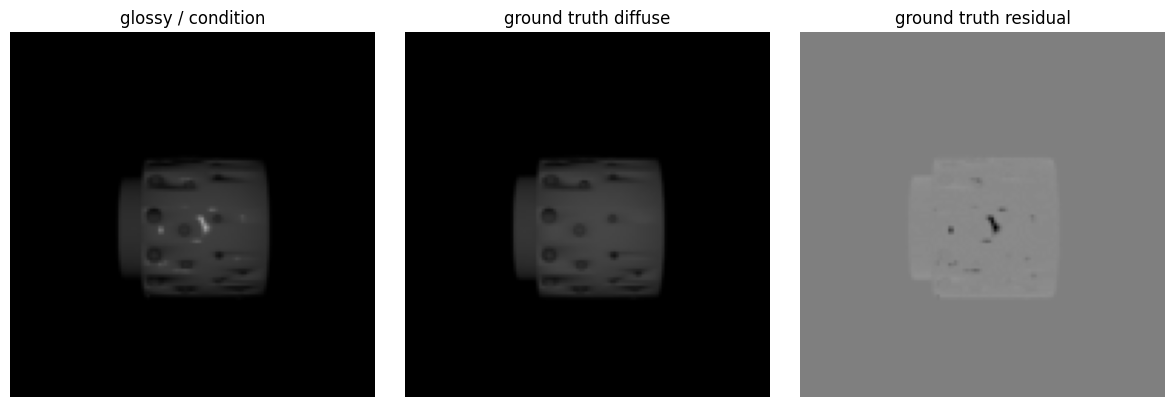

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

data_panels = [
    ("glossy / condition", condition[0]),
    ("ground truth diffuse", diffuse_gt[0]),
    ("ground truth residual", residual_gt[0]),
]

for axis, (title, tensor) in zip(axes.flat, data_panels):
    axis.imshow(chw_to_display(tensor))
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()


In [6]:
device = rt.resolve_device(DEVICE)


def load_model(checkpoint_info, device=device):
    model = rt.build_model(
        backbone_module=checkpoint_info["backbone_module"],
        model_name=checkpoint_info["model_name"],
        image_size=checkpoint_info["image_size"],
        noise_steps=checkpoint_info["noise_steps"],
        depth=checkpoint_info["depth"],
    ).to(device)
    model.load_state_dict(checkpoint_info["state_dict"])
    model.eval()
    return model


def sample_diffusion(model, input_field, noise_steps, device, parameterization="e", show_progress=False):
    model.eval(); model.to(device)
    diffuser = diff.CosSchDiffuser(noise_steps, device=device)

    if parameterization == "e":
        prediction = diffuser.sample_from_noise(model, input_field, show_progress=show_progress, ddim=False)
        return prediction

    if parameterization == "x":
        with torch.no_grad():
            x_t = torch.randn_like(input_field)
            t_now = torch.tensor([diffuser.steps], device=device).repeat(x_t.shape[0])
            t_pre = t_now - 1
            p_bar = tqdm(range(diffuser.steps)) if show_progress else range(diffuser.steps)

            for _ in p_bar:
                x0_pred = model(x_t, t_now, input_field)
                alpha_bar = diffuser.sqrt_alphas_bar[t_now]
                sigma = diffuser.sqrt_one_minus_alphas_bar[t_now].clamp_min(1e-12)
                predicted_noise = (x_t - alpha_bar * x0_pred) / sigma
                x_t = diffuser.DDPM_sample_step(x_t, t_now, t_pre, predicted_noise)
                t_now = t_pre
                t_pre = t_pre - 1

            return x_t

    raise ValueError(f"Unsupported parameterization: {parameterization}")


In [7]:
model = load_model(checkpoint_info, device=device)
print(f"model loaded on {device}")


model loaded on cuda


In [8]:
def run_inference(run_device):
    condition_run = condition.to(run_device)
    diffuse_gt_run = diffuse_gt.to(run_device)
    residual_gt_run = residual_gt.to(run_device)

    sampled_scaled_residual = sample_diffusion(
        model=model,
        input_field=condition_run,
        noise_steps=noise_steps,
        device=run_device,
        parameterization=parameterization,
        show_progress=SHOW_PROGRESS,
    )

    predicted_residual = sampled_scaled_residual / target_scale
    predicted_diffuse = condition_run + predicted_residual
    predicted_diffuse_clamped = predicted_diffuse.clamp(0.0, 1.0)

    residual_error = predicted_residual - residual_gt_run
    diffuse_error = predicted_diffuse - diffuse_gt_run
    diffuse_error_clamped = predicted_diffuse_clamped - diffuse_gt_run

    metrics = {
        "residual_mae": float(residual_error.abs().mean()),
        "residual_rmse": float(torch.sqrt((residual_error ** 2).mean())),
        "diffuse_mae": float(diffuse_error.abs().mean()),
        "diffuse_mae_clamped": float(diffuse_error_clamped.abs().mean()),
    }

    return {
        "runtime_device": str(run_device),
        "sampled_scaled_residual": sampled_scaled_residual.cpu(),
        "predicted_residual": predicted_residual.cpu(),
        "predicted_diffuse": predicted_diffuse.cpu(),
        "predicted_diffuse_clamped": predicted_diffuse_clamped.cpu(),
        "residual_error": residual_error.cpu(),
        "diffuse_error": diffuse_error.cpu(),
        "diffuse_error_clamped": diffuse_error_clamped.cpu(),
        "metrics": metrics,
    }


try:
    result = run_inference(device)
except RuntimeError as exc:
    if device.type == "cuda" and FALLBACK_TO_CPU_ON_CUDA_ERROR and is_cuda_runtime_error(exc):
        print(f"CUDA inference failed on {device}: {exc}")
        print("Retrying inference on CPU.")
        model.to("cpu")
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        result = run_inference(torch.device("cpu"))
    else:
        raise

runtime_device = result["runtime_device"]
sampled_scaled_residual = result["sampled_scaled_residual"]
predicted_residual = result["predicted_residual"]
predicted_diffuse = result["predicted_diffuse"]
predicted_diffuse_clamped = result["predicted_diffuse_clamped"]
residual_error = result["residual_error"]
diffuse_error = result["diffuse_error"]
diffuse_error_clamped = result["diffuse_error_clamped"]
metrics = result["metrics"]

print(f"runtime device: {runtime_device}")
metrics


CUDA inference failed on cuda: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
Retrying inference on CPU.


/pytorch/aten/src/ATen/native/cuda/IndexKernel.cu:113: operator(): block: [0,0,0], thread: [64,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernel.cu:113: operator(): block: [0,0,0], thread: [65,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernel.cu:113: operator(): block: [0,0,0], thread: [66,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernel.cu:113: operator(): block: [0,0,0], thread: [67,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernel.cu:113: operator(): block: [0,0,0], thread: [68,0,0] Assertion `-sizes[i] <= index && index < sizes[i] && "index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernel.cu:113: operator(): block: [0,0,0

AcceleratorError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

panels = [
    ("glossy / condition", condition[0]),
    ("ground truth diffuse", diffuse_gt[0]),
    ("pred diffuse", predicted_diffuse_clamped[0]),
    ("abs diffuse error", diffuse_error_clamped.abs()[0]),
    ("ground truth residual", residual_gt[0]),
    ("pred residual", predicted_residual[0]),
    ("abs residual error", residual_error.abs()[0]),
    ("pred scaled residual", sampled_scaled_residual[0]),
]

for axis, (title, tensor) in zip(axes.flat, panels):
    axis.imshow(chw_to_display(tensor))
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
summary = {
    "checkpoint": str(checkpoint_path),
    "state_key": state_key,
    "dataset_source": DATASET_SOURCE,
    "split": SPLIT,
    "sample_index": SAMPLE_INDEX,
    "device": str(device),
    "runtime_device": runtime_device,
    "backbone": backbone_module,
    "model": model_name,
    "image_size": image_size,
    "noise_steps": noise_steps,
    "depth": depth,
    "parameterization": parameterization,
    "target_scale": target_scale,
    "sampler": "Diffuser.CosSchDiffuser",
    **metrics,
}
pprint(summary)
